# RQ3 top-p

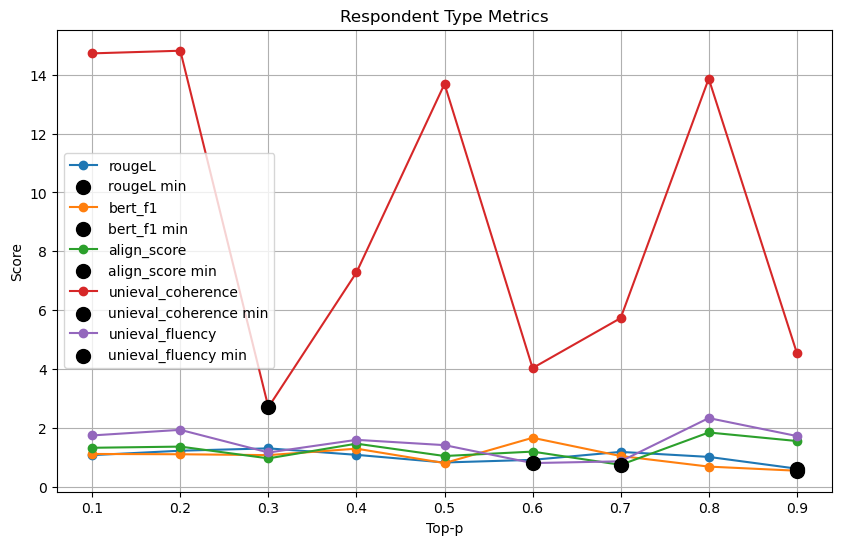

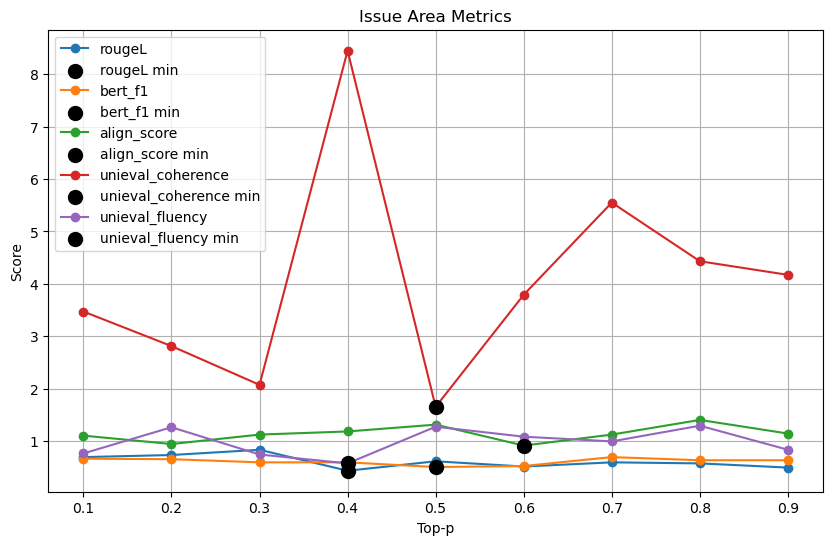

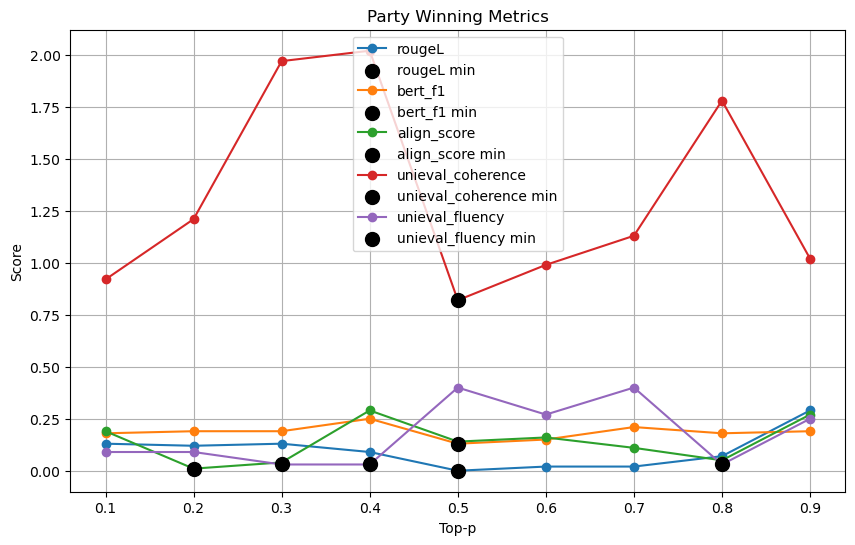

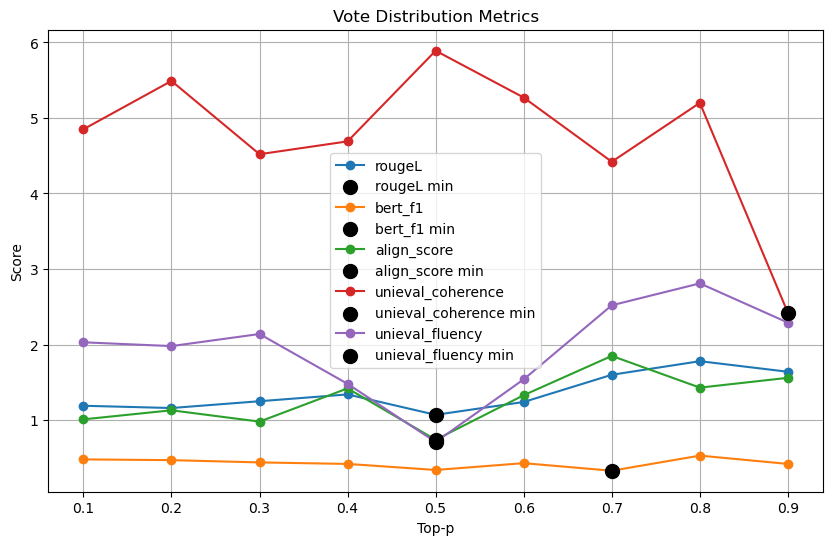

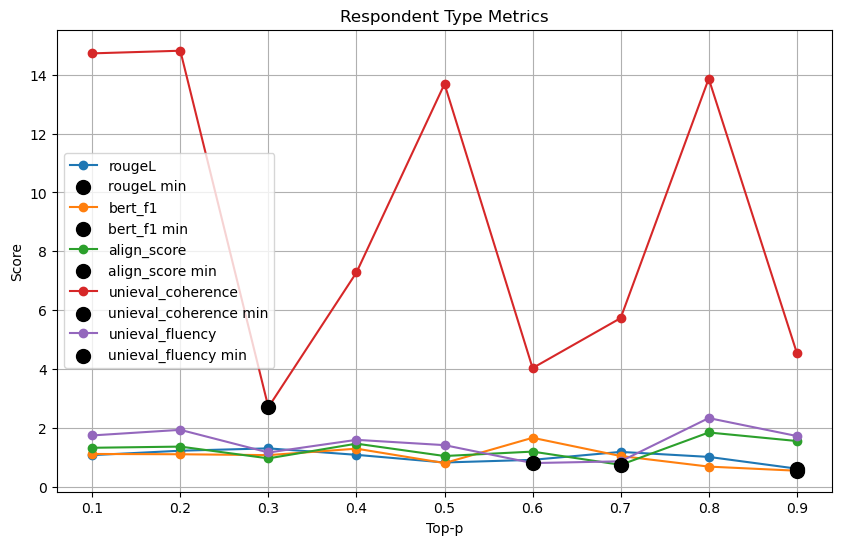

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for each section
decision_direction_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [0.20, 0.22, 0.04, 0.07, 0.03, 0.55, 0.45, 0.12, 0.67],
    # 'rouge2': [0.12, 0.05, 0.13, 0.04, 0.03, 0.19, 0.28, 0.07, 0.19],
    'rougeL': [0.04, 0.06, 0.12, 0.15, 0.19, 0.27, 0.26, 0.21, 0.14],
    'bert_f1': [0.23, 0.22, 0.28, 0.28, 0.23, 0.26, 0.21, 0.13, 0.23],
    'align_score': [0.38, 0.35, 0.43, 0.41, 0.20, 0.59, 0.32, 0.01, 0.17],
    'unieval_coherence': [0.32, 0.36, 0.43, 0.08,0.08, 1.45, 1.79, 0.11, 1.38],
    # 'unieval_consistency': [0.50, 0.54, 0.47, 0.57, 0.49, 0.24, 0.39, 0.25, 0.04],
    'unieval_fluency': [0.35, 0.16, 0.21, 0.29, 0.00, 0.13, 0.13, 0.33, 0.07]
}

issue_area_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [1.55, 1.79, 1.09, 2.13, 0.62, 1.59, 0.96, 2.04, 1.27],
    # 'rouge2': [1.00, 0.98, 0.77, 0.89, 0.71, 0.75, 0.19, 0.78, 0.78],
    'rougeL': [0.69, 0.73, 0.83, 0.43, 0.61, 0.51, 0.59, 0.57, 0.49],
    'bert_f1': [0.66, 0.65, 0.59, 0.59, 0.50, 0.52, 0.69, 0.63, 0.63],
    'align_score': [1.10, 0.94, 1.12, 1.18, 1.31, 0.91, 1.12, 1.40, 1.14],
    'unieval_coherence': [3.47, 2.81, 2.07, 8.45, 1.65, 3.79, 5.55, 4.43, 4.17],
    # 'unieval_consistency': [1.88, 1.22, 2.12, 1.91, 2.36, 2.12, 1.47, 1.76, 1.98],
    'unieval_fluency': [0.76, 1.26, 0.74, 0.57, 1.27, 1.08, 0.99, 1.29, 0.83]
}

party_winning_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [0.14, 0.18, 0.01, 0.15, 0.28, 0.63, 0.04, 0.14, 0.50],
    # 'rouge2': [0.29, 0.31, 0.15, 0.18, 0.27, 0.48, 0.21, 0.35, 0.11],
    'rougeL': [0.13, 0.12, 0.13, 0.09, 0.00, 0.02, 0.02, 0.07, 0.29],
    'bert_f1': [0.18, 0.19, 0.19, 0.25, 0.13, 0.15, 0.21, 0.18, 0.19],
    'align_score': [0.19, 0.01, 0.04, 0.29, 0.14, 0.16, 0.11, 0.05, 0.27],
    'unieval_coherence': [0.92, 1.21, 1.97, 2.02, 0.82, 0.99, 1.13, 1.78, 1.02],
    # 'unieval_consistency': [0.27, 0.28, 0.25, 0.16, 0.48, 0.27, 0.41, 0.47, 0.20],
    'unieval_fluency': [0.09, 0.09, 0.03, 0.03, 0.40, 0.27, 0.40, 0.03, 0.25]
}

vote_distribution_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [2.59, 2.51, 2.55, 2.49, 3.12, 3.82, 2.77, 5.00, 4.61],
    # 'rouge2': [1.54, 1.49, 1.50, 1.61, 1.41, 1.84, 2.08, 2.44, 2.33],
    'rougeL': [1.19, 1.16, 1.25, 1.34, 1.07, 1.24, 1.60, 1.78, 1.64],
    'bert_f1': [0.48, 0.47, 0.44, 0.42, 0.34, 0.43, 0.33, 0.53, 0.42],
    'align_score': [1.01, 1.13, 0.98, 1.42, 0.74, 1.33, 1.85, 1.43, 1.56],
    'unieval_coherence': [4.85, 5.49, 4.52, 4.69, 5.89, 5.27, 4.42, 5.20, 2.42],
    # 'unieval_consistency': [2.62, 2.63, 2.45, 1.36, 0.33, 0.49, 2.09, 2.15, 1.47],
    'unieval_fluency': [2.03, 1.98, 2.14, 1.48, 0.71, 1.54, 2.52, 2.81, 2.29]
}


respondent_type_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [0.80, 0.77, 1.49, 1.50, 1.19, 2.05, 1.15, 0.76, 0.39],
    # 'rouge2': [0.92, 0.99, 1.47, 1.56, 0.64, 1.33, 1.47, 0.72, 0.48],
    'rougeL': [1.07, 1.22, 1.30, 1.08, 0.82, 0.91, 1.18, 1.01, 0.61],
    'bert_f1': [1.11, 1.10, 1.07, 1.29, 0.80, 1.66, 1.04, 0.68, 0.54],
    'align_score': [1.32, 1.36, 0.96, 1.46, 1.04, 1.19, 0.74, 1.84, 1.55],
    'unieval_coherence': [14.73, 14.82, 2.70, 7.28, 13.69, 4.03, 5.73, 13.87, 4.55],
    # 'unieval_consistency': [2.94, 3.80, 2.90, 0.93, 3.85, 1.23, 2.44, 2.11, 2.13],
    'unieval_fluency': [1.74, 1.93, 1.16, 1.59, 1.41, 0.80, 0.86, 2.33, 1.72]
}

respondent_type_df = pd.DataFrame(respondent_type_data)
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)



def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        y = df[column]
        plt.plot(df['top-p'], y, marker='o', label=column)
        
        # Highlight the minimum value
        min_value = y.min()
        min_indices = y[y == min_value].index
        plt.scatter(df['top-p'][min_indices], y[min_indices], color='black', s=100, zorder=5, label=f'{column} min')
    
    plt.title(title)
    plt.xlabel('Top-p')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the Respondent Type metrics
plot_metrics(respondent_type_df, 'Respondent Type Metrics')
# plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')

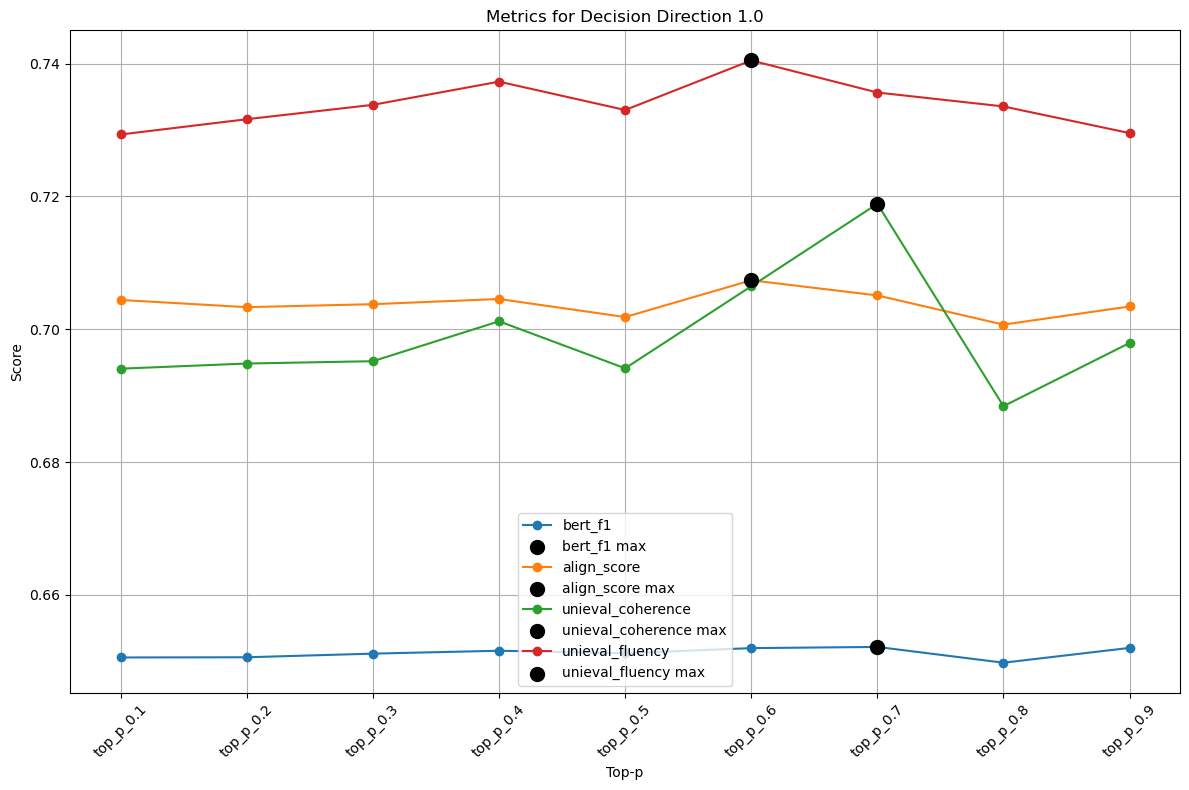

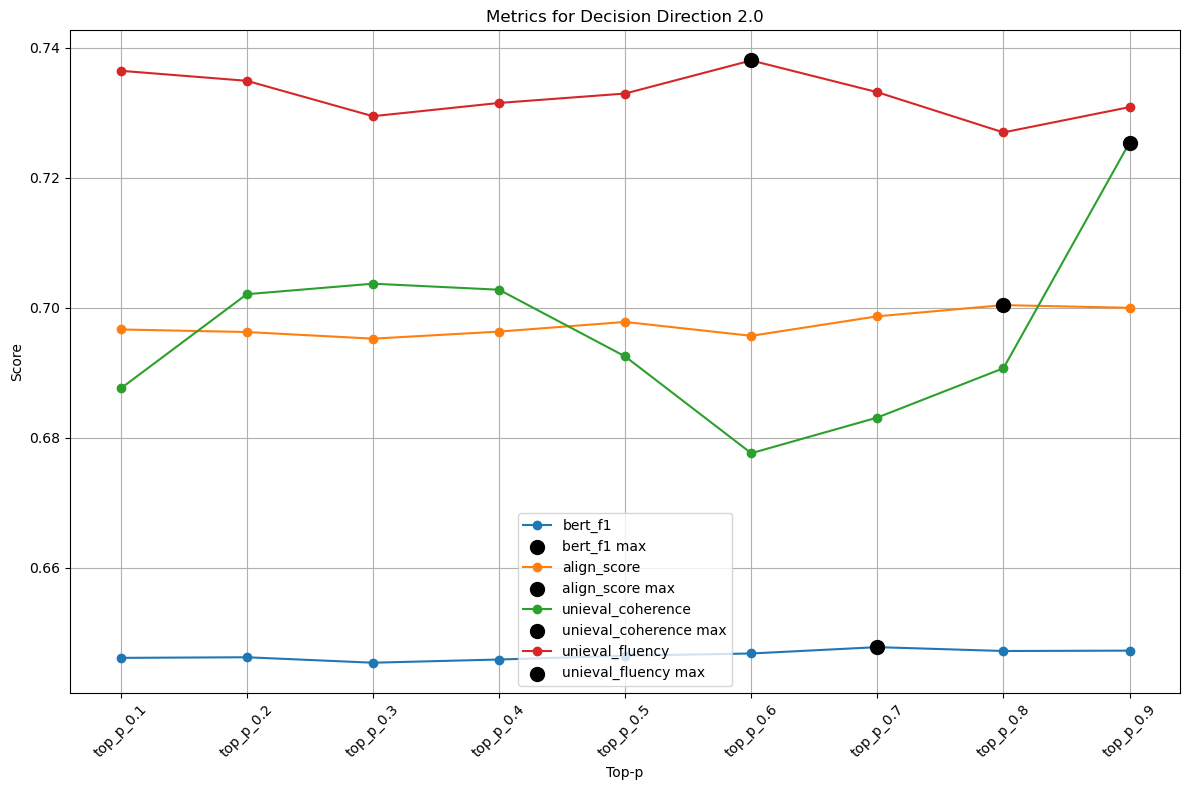

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for plotting
data = {
    'top-p': [
        'top_p_0.4', 'top_p_0.4', 'top_p_0.7', 'top_p_0.7', 'top_p_0.6', 'top_p_0.6',
        'top_p_0.1', 'top_p_0.1', 'top_p_0.3', 'top_p_0.3', 'top_p_0.5', 'top_p_0.5',
        'top_p_0.9', 'top_p_0.9', 'top_p_0.8', 'top_p_0.8', 'top_p_0.2', 'top_p_0.2'
    ],
    'decisionDirection': [
        1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0
    ],
    # 'rouge1': [
    #     0.5484612102696781, 0.5471841678365582, 0.564739067264348, 0.5557140972671861,
    #     0.5628965311796577, 0.5519169164400468, 0.5506092857063648, 0.5547205083212373,
    #     0.5546073567514791, 0.5537891260307567, 0.5516887373239537, 0.5511726238008546,
    #     0.5618519211942052, 0.5483964684822924, 0.5580600996538002, 0.5557013371857054,
    #     0.5524135966877824, 0.5568911540176398
    # ],
    # 'rouge2': [
    #     0.2726076729008805, 0.2718188485573092, 0.2812881115164121, 0.2757166866642853,
    #     0.2794121839991516, 0.2755791965325911, 0.272747697309404, 0.274976460134362,
    #     0.2766634150212583, 0.2742360192327985, 0.2733725891597403, 0.2728404948484281,
    #     0.2764834849076197, 0.2726769480831236, 0.276058660724974, 0.2747452762927795,
    #     0.2735864747878113, 0.2746083127314495
    # ],
    # 'rougeL': [
    #     0.2474086679377824, 0.2443308926374587, 0.252663409623622, 0.2474758872589944,
    #     0.2510963568337907, 0.2457637137599458, 0.2476736673207688, 0.2468347108526212,
    #     0.2493639740433672, 0.247071435316609, 0.2480933639222508, 0.2442763776453936,
    #     0.2491688807368653, 0.2465353443695454, 0.2507418014517264, 0.2465511888604699,
    #     0.2482580094551086, 0.2470539918434638
    # ],
    'bert_f1': [
        0.6515744237499382, 0.6458921279823571, 0.6521482713349903, 0.6477945359129654,
        0.6519692626618246, 0.6468190090698108, 0.6505609869046975, 0.6461457639409784,
        0.6511381031902692, 0.6453987843111941, 0.6511953072693512, 0.6464788629297624,
        0.652003166102271, 0.6472581524597971, 0.6497708028964414, 0.6471994054944892,
        0.6505919358202519, 0.6462378014597976
    ],
    'align_score': [
        0.704552003445516, 0.6963257004294479, 0.7050905207186254, 0.6986788279131839,
        0.7073705762852239, 0.6956763912711227, 0.7044092902472912, 0.6966538276588707,
        0.7037704018236116, 0.6952385061665585, 0.7018337777552713, 0.6978099633727157,
        0.7034265467228781, 0.6999836181339465, 0.7006933816516673, 0.7004005931971365,
        0.7033233871214263, 0.6962600576250176
    ],
    'unieval_coherence': [
        0.7011916827500493, 0.702767430957576, 0.718888912954976, 0.6831067252792651,
        0.7064697962581711, 0.6776197656335967, 0.6940570369093015, 0.6875781826087782,
        0.6951837165869718, 0.7036939550893726, 0.6941155771549196, 0.692506671073341,
        0.6979264183645628, 0.7254015123702534, 0.6884118877370466, 0.690693282100818,
        0.6948345763188154, 0.702077918578732
    ],
    'unieval_fluency': [
        0.7372894932108162, 0.7314921785671802, 0.73565302201374, 0.733148251988901,
        0.7404824175148554, 0.7380307059937883, 0.7293331711758247, 0.7364400601214811,
        0.7337963689079364, 0.7294562017987868, 0.7330204108133727, 0.7329408940121316,
        0.7295442710399217, 0.7308542020067167, 0.7335551666253707, 0.7269612823751859,
        0.731631704862369, 0.7348985053399643
    ]}

import pandas as pd
import matplotlib.pyplot as plt

# Assuming the data is already in a DataFrame called df
df = pd.DataFrame(data)

# Sort the DataFrame by 'top-p'
df['top-p'] = pd.Categorical(df['top-p'], categories=sorted(df['top-p'].unique(), key=lambda x: float(x.split('_')[-1])), ordered=True)
df = df.sort_values('top-p')

# Split the DataFrame based on 'decisionDirection'
df_decision_1 = df[df['decisionDirection'] == 1.0]
df_decision_2 = df[df['decisionDirection'] == 2.0]

def plot_metrics(df, title):
    plt.figure(figsize=(12, 8))
    for column in df.columns[2:]:  # Skip 'top-p' and 'decisionDirection'
        y = df[column]
        plt.plot(df['top-p'], y, marker='o', label=column)
        
        # Highlight the maximum value
        max_value = y.max()
        max_indices = y[y == max_value].index
        plt.scatter(df['top-p'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')
    
    plt.title(title)
    plt.xlabel('Top-p')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the metrics for each decision direction
plot_metrics(df_decision_1, 'Metrics for Decision Direction 1.0')
plot_metrics(df_decision_2, 'Metrics for Decision Direction 2.0')



In [2]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('/home/mostah/workspace/fairness/scores/grouped average scores/issueArea.csv')

# Display the first few rows of the DataFrame
# print(df.head())
column_names = df.columns
# print(column_names)
filtered_df = df[df['Model Name'].str.contains('top_p_')]
filtered_df = filtered_df.drop(columns=['rougeL','rouge1', 'rouge2', 'unieval_relevance', 'unieval_overall','unieval_consistency'])


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(df, title):
    # Filter the DataFrame to include only rows where 'issueArea' <= 5
    filtered_df = df[df['issueArea'] <= 5]
    
    # Sort the DataFrame by 'Model Name'
    sorted_df = filtered_df.sort_values(by='Model Name')
    
    plt.figure(figsize=(12, 8))
    for column in sorted_df.columns[2:]:  # Skip 'Model Name' and 'issueArea'
        y = sorted_df[column]
        plt.plot(sorted_df['Model Name'], y, marker='o', label=column)
        
        # Highlight the maximum value
        max_value = y.max()
        max_indices = y[y == max_value].index
        plt.scatter(sorted_df['Model Name'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')
    
    plt.title(title)
    plt.xlabel('Model Name')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage
# df = pd.read_csv('your_file.csv')  # Load your DataFrame
# plot_metrics(df, 'Sorted and Filtered Metrics Plot')



plot_metrics(filtered_df, 'Filtered Metrics Plot')

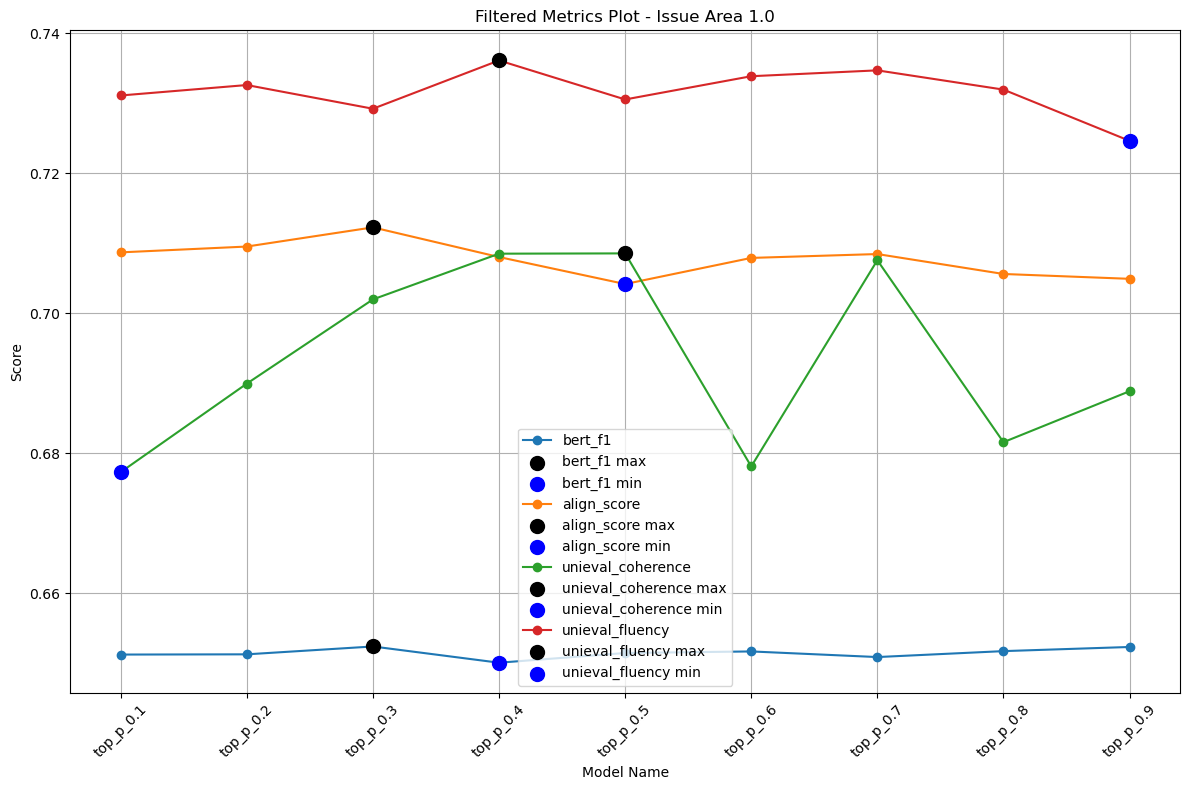

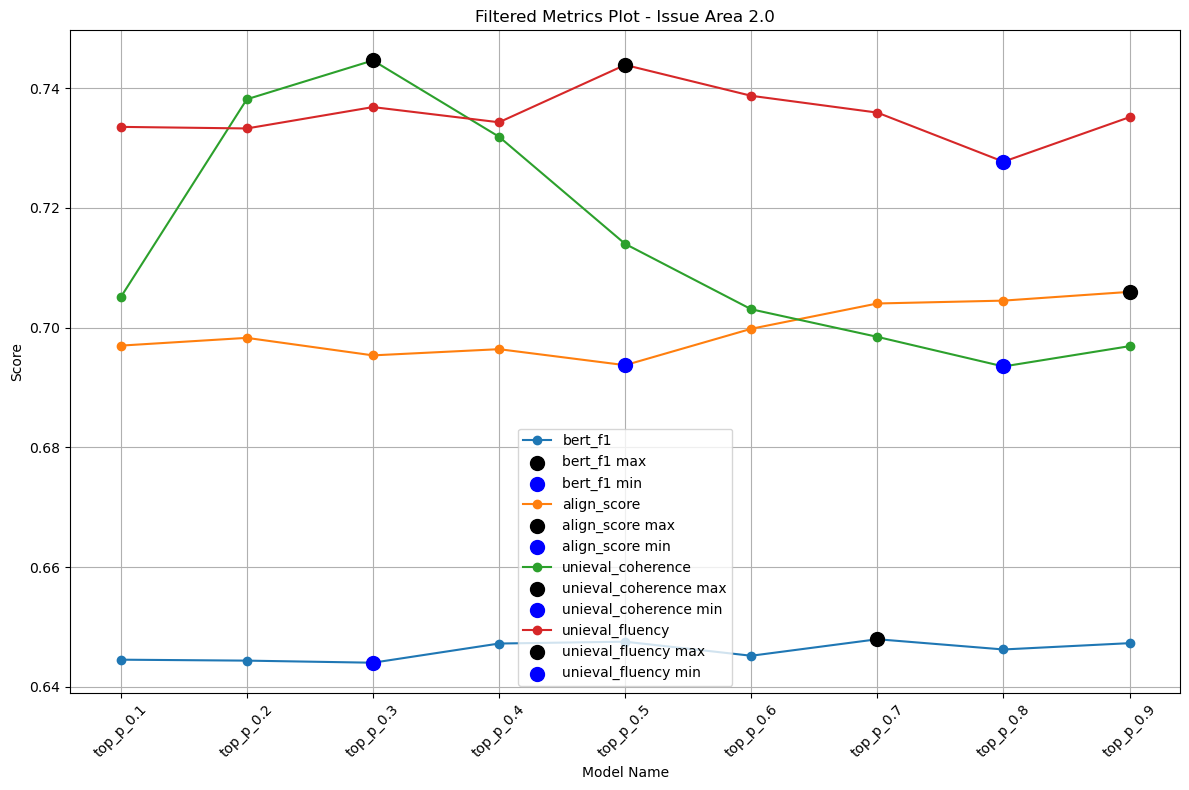

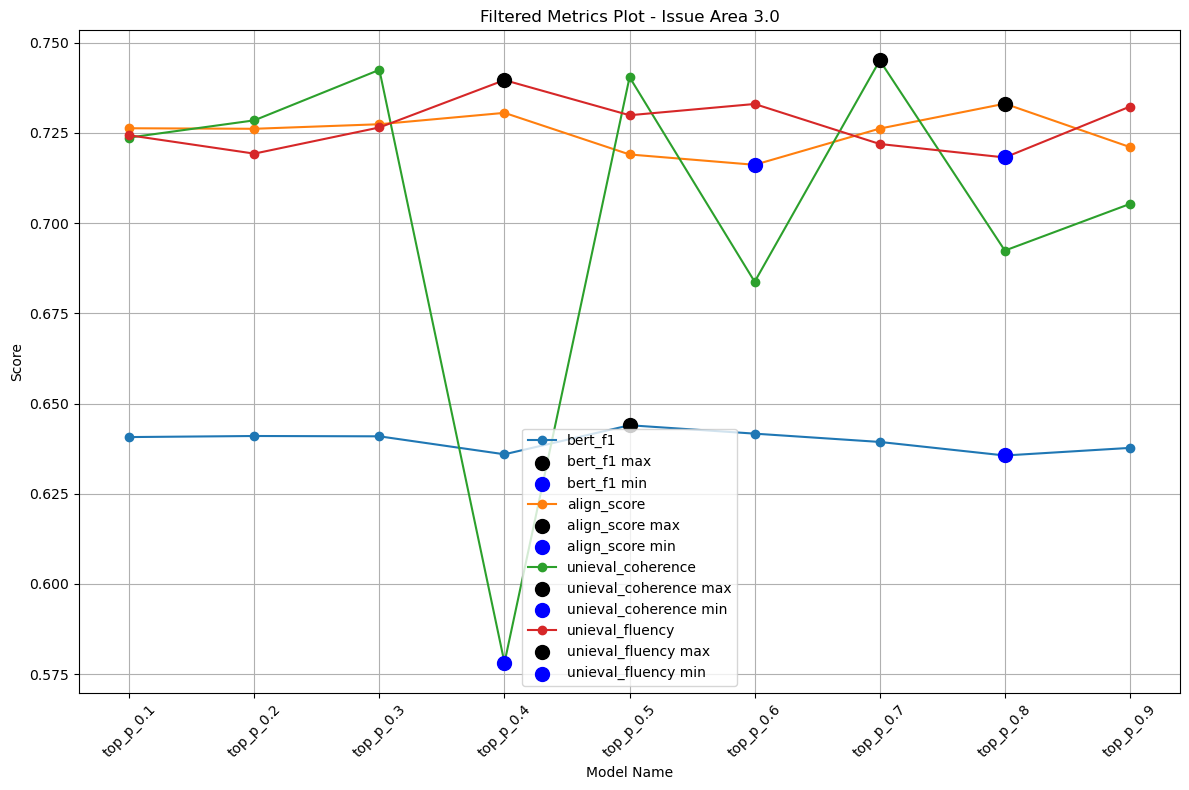

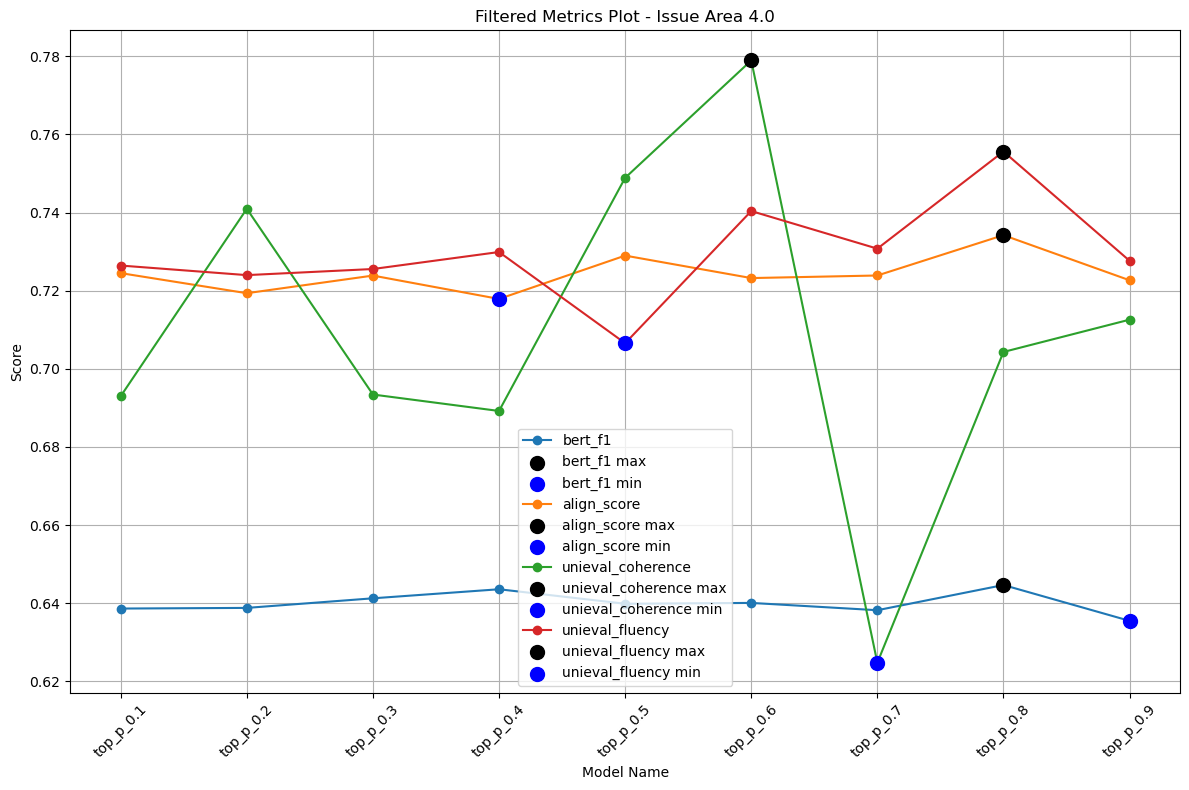

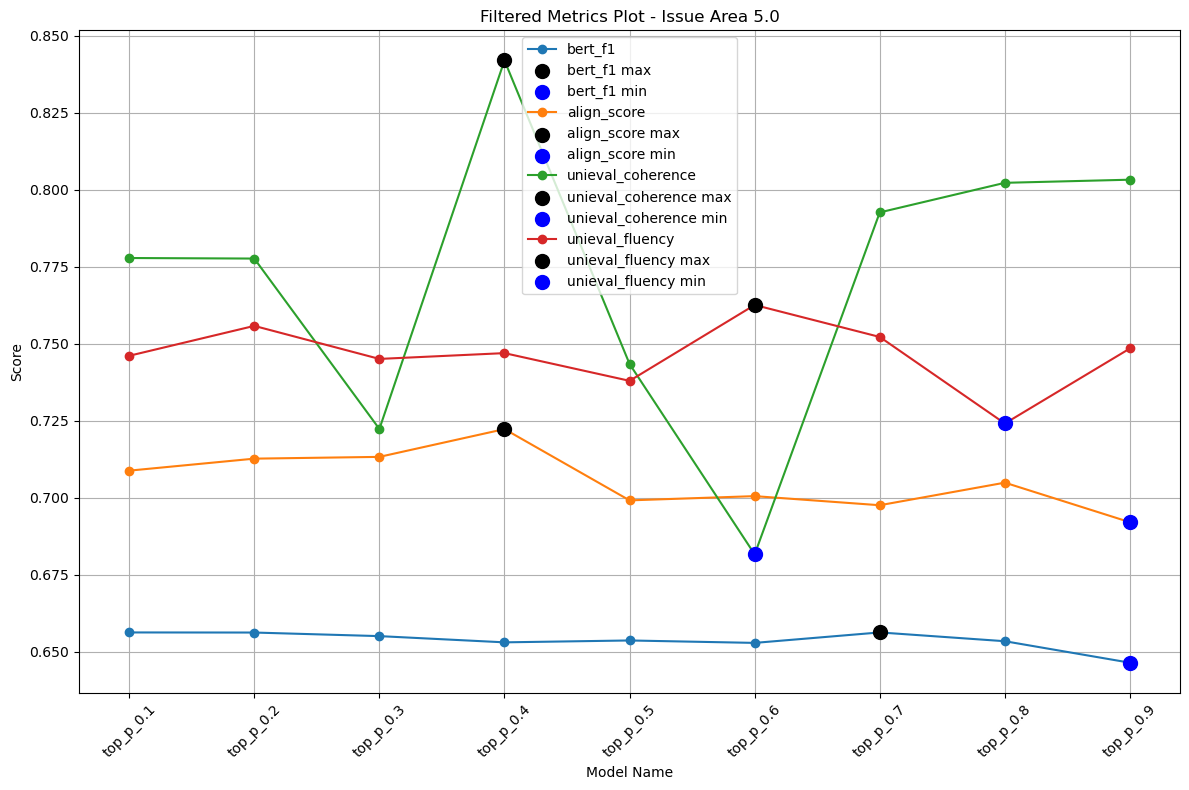

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(df, title_prefix):
    filtered_df = df[df['issueArea'] <= 5]
    # Sort the DataFrame by 'Model Name'
    sorted_df = filtered_df.sort_values(by='Model Name')
    # Group the DataFrame by 'issueArea'
    grouped = sorted_df.groupby('issueArea')
    
    # Iterate over each group
    for issue_area, group in grouped:
        plt.figure(figsize=(12, 8))
        for column in group.columns[2:]:  # Skip 'Model Name' and 'issueArea'
            y = group[column]
            plt.plot(group['Model Name'], y, marker='o', label=column)
            
            # Highlight the maximum value
            max_value = y.max()
            max_indices = y[y == max_value].index
            plt.scatter(group['Model Name'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')

            min_value = y.min()
            min_indices = y[y == min_value].index
            plt.scatter(group['Model Name'][min_indices], y[min_indices], color='blue', s=100, zorder=5, label=f'{column} min')
        
        plt.title(f"{title_prefix} - Issue Area {issue_area}")
        plt.xlabel('Model Name')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Example usage
# df = pd.read_csv('your_file.csv')  # Load your DataFrame
# plot_metrics(df, 'Metrics Plot')

plot_metrics(filtered_df, 'Filtered Metrics Plot')


In [7]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('/home/mostah/workspace/fairness/scores/grouped average scores/partyWinning.csv')

# Display the first few rows of the DataFrame
# print(df.head())
column_names = df.columns
# print(column_names)
filtered_df = df[df['Model Name'].str.contains('top_p_')]
filtered_df = filtered_df.drop(columns=['rougeL','rouge1', 'rouge2', 'unieval_relevance', 'unieval_overall','unieval_consistency'])

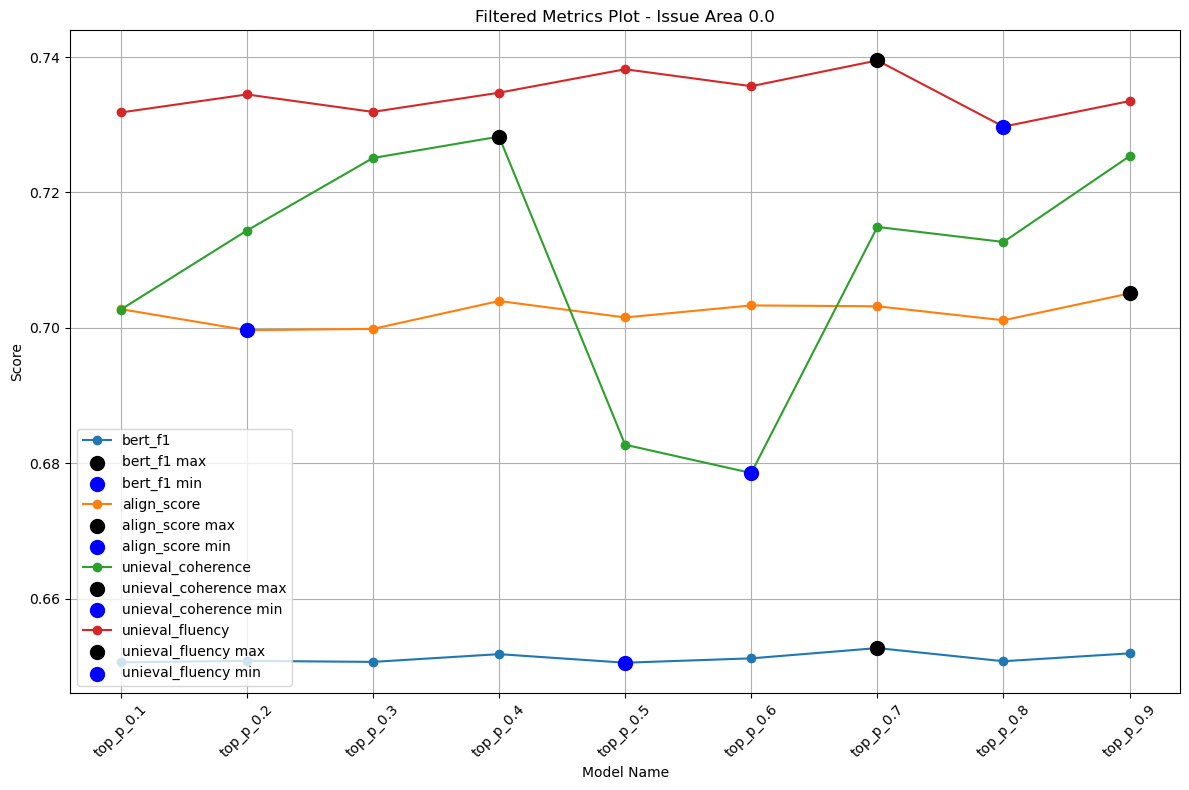

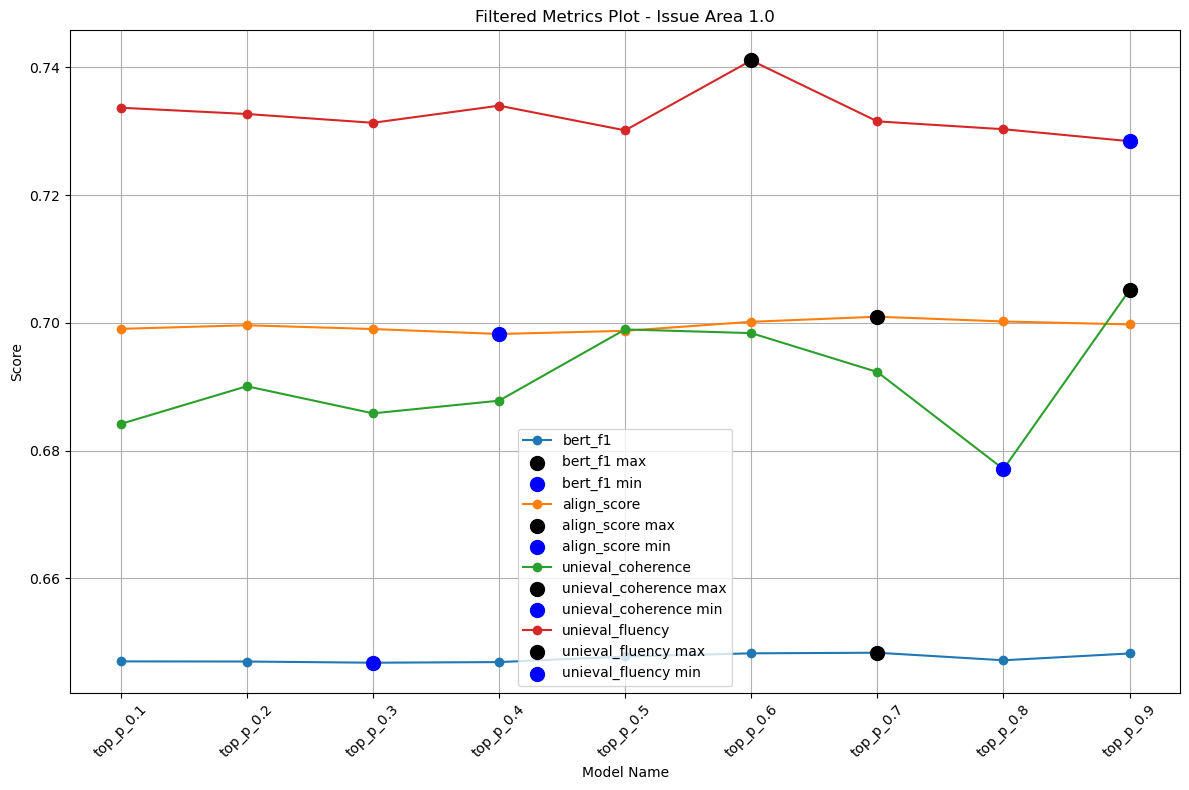

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(df, title_prefix):
    # Sort the DataFrame by 'Model Name'
    sorted_df = filtered_df.sort_values(by='Model Name')
    # Group the DataFrame by 'issueArea'
    grouped = sorted_df.groupby('partyWinning')
    
    # Iterate over each group
    for issue_area, group in grouped:
        plt.figure(figsize=(12, 8))
        for column in group.columns[2:]:  # Skip 'Model Name' and 'issueArea'
            y = group[column]
            plt.plot(group['Model Name'], y, marker='o', label=column)
            
            # Highlight the maximum value
            max_value = y.max()
            max_indices = y[y == max_value].index
            plt.scatter(group['Model Name'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')

            min_value = y.min()
            min_indices = y[y == min_value].index
            plt.scatter(group['Model Name'][min_indices], y[min_indices], color='blue', s=100, zorder=5, label=f'{column} min')
        
        plt.title(f"{title_prefix} - Issue Area {issue_area}")
        plt.xlabel('Model Name')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Example usage
# df = pd.read_csv('your_file.csv')  # Load your DataFrame
# plot_metrics(df, 'Metrics Plot')

plot_metrics(filtered_df, 'Filtered Metrics Plot')
